<a href="https://colab.research.google.com/github/djlakhani/spuco_BigML/blob/main/spuco_bigml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spurious Correlations BigML Application Project

In [1]:
%%capture
%pip install spuco;

In [2]:
#imports

import pandas as pd
import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader

In [3]:
# loading datasets
# code below is from SpuCo Quickstart Notebook tutorials

from spuco.datasets import SpuCoMNIST, SpuriousFeatureDifficulty
import torchvision.transforms as T

# 5 superclasses, with 2 subclasses in each
classes = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
difficulty = SpuriousFeatureDifficulty.MAGNITUDE_LARGE

trainset = SpuCoMNIST(
    root="/data/mnist/",
    spurious_feature_difficulty=difficulty,
    spurious_correlation_strength=0.995,
    classes=classes,
    split="train"
)
trainset.initialize()

testset = SpuCoMNIST(
    root="/data/mnist/",
    spurious_feature_difficulty=difficulty,
    classes=classes,
    split="test"
)
testset.initialize()

100%|██████████| 9.91M/9.91M [00:00<00:00, 54.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.80MB/s]


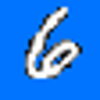

In [4]:
# displaying image from our dataset
# the background colors are the spurious feature
T.ToPILImage()(trainset[12][0]).resize((100,100))

## 1) Train a model using ERM

In [5]:
# dividing data into batches

train_loader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

In [6]:
test_loader = DataLoader(
    testset,
    batch_size=64,
    shuffle=True
)

In [7]:
# saving linear layer of CNN
all_class = torch.randn(1, 784)
all_class_labels = torch.tensor(np.array([1]))

In [150]:
# a simple CNN model

import torch.nn as nn
import torch.nn.functional as F

class spucoCNN(nn.Module):
    def __init__(self, n_class):
        super().__init__()
        self.n_class = n_class

        self.conv1 = nn.Conv2d(3, 6, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(6, 12, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(12, 16, kernel_size=3, stride=2, padding=1)

        self.classifier = nn.Linear(784, self.n_class)

        self.relu = nn.ReLU()

    def forward(self, x, save_linear=False):
        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        x3 = self.relu(self.conv3(x2))
        x3 = torch.flatten(x3, start_dim=1)
        save_linear = x3.clone()
        classified = self.classifier(x3)

        return classified, save_linear

In [151]:
# writing a training loop
import numpy as np

spucoCNN_model = spucoCNN(n_class = 5)

# update weights
optimizer = torch.optim.AdamW(spucoCNN_model.parameters(), lr = 0.001)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = torch.nn.CrossEntropyLoss()
spucoCNN_model = spucoCNN_model.to(device)

def train():

  num_epoch = 2

  for epoch in range(num_epoch):
    spucoCNN_model.train()
    for iter, (inputs, labels) in enumerate(train_loader):
      optimizer.zero_grad()
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = spucoCNN_model.forward(inputs)  # ouputs = logits, linear_layer
      predicted_labels = torch.argmax(outputs[0], axis=1)
      accuracy = np.mean(np.array(labels == predicted_labels))

      loss = criterion(outputs[0], labels)
      loss.backward()
      optimizer.step()

      if iter % 100 == 0:
          print(f"epoch {epoch}, iter {iter}, loss: {loss.item()}, accuracy: {accuracy}")


# training the model
train()

TypeError: 'int' object is not callable

In [10]:
# evaluating model performance before GDRO
def test():
  spucoCNN_model.eval()
  for iter, (inputs, labels) in enumerate(test_loader):
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = spucoCNN_model.forward(inputs)  # ouputs = logits, linear_layer
    predicted_labels = torch.argmax(outputs[0], axis=1)
    accuracy = np.mean(np.array(labels == predicted_labels))

    if iter % 50 == 0:
          print(f"iter {iter}, accuracy: {accuracy}")

test()

iter 0, accuracy: 0.171875
iter 50, accuracy: 0.28125
iter 100, accuracy: 0.171875
iter 150, accuracy: 0.171875


The massive discrepancy between the training accuracy and the testing accuracy indicates that our model is utilizing the spurious feature (background color) to make classifications.

## 2) Dimensionality reduction and clustering of CNN linear layer

In [92]:
# creating new trainset to accomodate subclass labels
trainset_subclass = []
for img, sup in trainset:
  trainset_subclass.append((img, sup, -1))
print(len(trainset_subclass))

48004


In [102]:
# saving the linear layer for each image
trainset_subclass_loader = DataLoader(
    trainset_subclass,
    batch_size=64,
    shuffle=False
)

#reset globals before calling again
def separate_classes():
  global all_class, all_class_labels
  for iter, (inputs, labels, subclass_labels) in enumerate(trainset_subclass_loader):
    inputs = inputs.to(device)
    labels = labels.to(device)
    # subclass_labels = -1

    outputs = spucoCNN_model.forward(inputs)  # ouputs = logits, linear_layer
    all_class = torch.cat((all_class, outputs[1]), 0)
    all_class_labels = torch.cat((all_class_labels, labels), 0)

separate_classes()

In [103]:
# removing first rand entry of all_class and all_class_labels

all_class = all_class[1:]
all_class_labels = all_class_labels[1:]

print(all_class.shape)
print(all_class_labels.shape)

torch.Size([48004, 784])
torch.Size([48004])


In [105]:
# ensuring order is preserved
idx = 0
for (img, sup, sub) in trainset_subclass:
  if (all_class_labels[idx] != sup):
    print("order not maintained")
    break
  idx = idx + 1

In [106]:
# reducing dimensions 784 -> 2 before clustering
# umap recommended in George demo

import umap
reducer = umap.UMAP()
embedding = reducer.fit_transform(all_class.detach().numpy())
embedding.shape

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(48004, 2)

In [107]:
# seperating all the super-classes for classification
class0 = embedding[all_class_labels == 0]
class1 = embedding[all_class_labels == 1]
class2 = embedding[all_class_labels == 2]
class3 = embedding[all_class_labels == 3]
class4 = embedding[all_class_labels == 4]

In [108]:
print(class0.shape)
print(class1.shape)
print(class2.shape)
print(class3.shape)
print(class4.shape)

(10133, 2)
(9672, 2)
(9011, 2)
(9747, 2)
(9441, 2)


In [109]:
# clustering class 0 superclass [0, 1] into two subclasses
from sklearn.cluster import KMeans
kmeans0 = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans0.fit(class0)
labels0 = kmeans0.labels_

Text(0.5, 1.0, 'Superclass 0 [0, 1] Clusters')

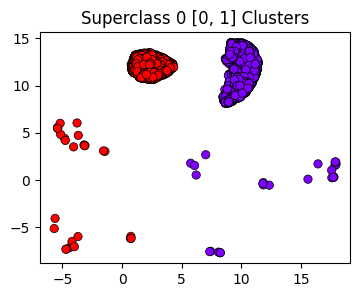

In [110]:
# plotting class0 clusters
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 3))
plt.scatter(class0[:, 0], class0[:, 1],
            c=labels0,
            cmap='rainbow',
            edgecolors='black',
            linewidths=0.5)
plt.title("Superclass 0 [0, 1] Clusters")

In [111]:
# generating labels for the other superclasses
kmeans1 = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans1.fit(class1)
labels1 = kmeans1.labels_

kmeans2 = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans2.fit(class2)
labels2 = kmeans2.labels_

kmeans3 = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans3.fit(class3)
labels3 = kmeans3.labels_

kmeans4 = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans4.fit(class4)
labels4 = kmeans4.labels_

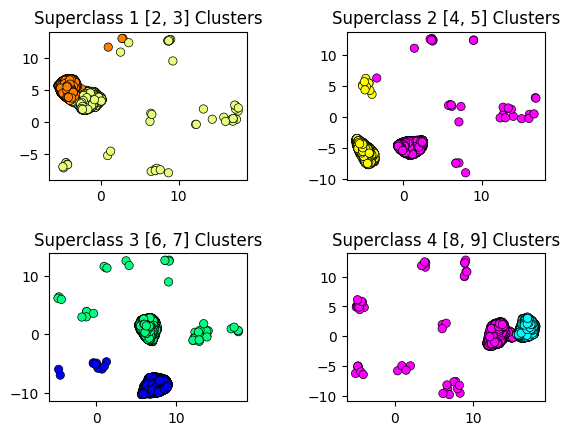

In [112]:
# plotting the rest of the superclass clusters
fig, axs = plt.subplots(2, 2)
axs[0, 0].scatter(class1[:, 0], class1[:, 1],
                  c=labels1,
                  cmap='Wistia',
                  edgecolors='black',
                  linewidths=0.5)
axs[0, 0].set_title("Superclass 1 [2, 3] Clusters")

axs[0, 1].scatter(class2[:, 0], class2[:, 1],
                  c=labels2,
                  cmap='spring',
                  edgecolors='black',
                  linewidths=0.5)
axs[0, 1].set_title("Superclass 2 [4, 5] Clusters")

axs[1, 0].scatter(class3[:, 0], class3[:, 1],
                  c=labels3,
                  cmap='winter',
                  edgecolors='black',
                  linewidths=0.5)
axs[1, 0].set_title("Superclass 3 [6, 7] Clusters")

axs[1, 1].scatter(class4[:, 0], class4[:, 1],
                  c=labels4,
                  cmap='cool',
                  edgecolors='black',
                  linewidths=0.5)
axs[1, 1].set_title("Superclass 4 [8, 9] Clusters")

plt.subplots_adjust(wspace=0.5)
plt.subplots_adjust(hspace=0.5)
plt.show()

In [113]:
# initializing subclass labels in trainset list
idx0 = 0
idx1 = 0
idx2 = 0
idx3 = 0
idx4 = 0
idx = 0

for img, sup, sub in trainset_subclass:
  if sup == 0:
    trainset_subclass[idx] = (img, sup, labels0[idx0])
    idx0 = idx0 + 1
  elif sup == 1:
    trainset_subclass[idx] = (img, sup, labels1[idx1])
    idx1 = idx1 + 1
  elif sup == 2:
    trainset_subclass[idx] = (img, sup, labels2[idx2])
    idx2 = idx2 + 1
  elif sup == 3:
    trainset_subclass[idx] = (img, sup, labels3[idx3])
    idx3 = idx3 + 1
  elif sup == 4:
    trainset_subclass[idx] = (img, sup, labels4[idx4])
    idx4 = idx4 + 1
  idx = idx + 1

In [126]:
# rough testing to check subclass pairs in superclass
i = 0
for img, sup, sub in trainset_subclass:
  print(f"index {i}, super_class_label {sup}, sub_class_label {sub}")
  i = i + 1
  if i > 10:
    break

index 0, super_class_label 2, sub_class_label 1
index 1, super_class_label 0, sub_class_label 1
index 2, super_class_label 2, sub_class_label 0
index 3, super_class_label 0, sub_class_label 0
index 4, super_class_label 4, sub_class_label 1
index 5, super_class_label 1, sub_class_label 0
index 6, super_class_label 0, sub_class_label 0
index 7, super_class_label 1, sub_class_label 1
index 8, super_class_label 0, sub_class_label 0
index 9, super_class_label 2, sub_class_label 0
index 10, super_class_label 2, sub_class_label 1


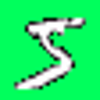

In [127]:
# image at index 0 has super class 2 and subclass 1
T.ToPILImage()(trainset_subclass[0][0]).resize((100,100))

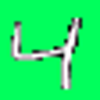

In [129]:
# image at index 2 has super class 2 and subclass 0
T.ToPILImage()(trainset_subclass[2][0]).resize((100,100))

## 3) Retraining CNN using subclass labels and minimizing robust loss

In [130]:
trainset_subclass_shuffled_loader = DataLoader(
    trainset_subclass,
    batch_size=128,
    shuffle=True
)

In [135]:
# retraining model with subclass labels
def train_subclass():
  num_epoch = 2

  for epoch in range(num_epoch):
    spucoCNN_model.train()
    for iter, (inputs, labels, subclass_labels) in enumerate(trainset_subclass_shuffled_loader):
      optimizer.zero_grad()
      inputs = inputs.to(device)
      labels = labels.to(device)
      subclass_labels = subclass_labels.to(device)

      outputs = spucoCNN_model.forward(inputs)  # ouputs = logits, linear_layer
      predicted_labels = torch.argmax(outputs[0], axis=1)
      accuracy = np.mean(np.array(labels == predicted_labels))

      # computing loss for each subclass
      loss = criterion(outputs[0], labels)
      for sup in range(5):
        outputs_filtered = outputs[0][labels == sup]
        labels_filtered = labels[labels == sup]
        subclass_labels_filtered = subclass_labels[labels == sup]
        for sub in range(2):
          outputs_filtered_sub = outputs_filtered[subclass_labels_filtered == sub]
          labels_filtered_sub = labels_filtered[subclass_labels_filtered == sub]
          loss_sub = criterion(outputs_filtered_sub, labels_filtered_sub)
          if loss_sub > loss:
            loss = loss_sub

      # loss = criterion(outputs[0], labels)
      loss.backward()
      optimizer.step()

      if iter % 100 == 0:
          print(f"epoch {epoch}, iter {iter}, loss: {loss.item()}, accuracy: {accuracy}")

train_subclass()

epoch 0, iter 0, loss: 0.008102652616798878, accuracy: 1.0
epoch 0, iter 100, loss: 0.06873013824224472, accuracy: 1.0
epoch 0, iter 200, loss: 0.45585203170776367, accuracy: 0.9921875
epoch 0, iter 300, loss: 0.04257832467556, accuracy: 1.0
epoch 1, iter 0, loss: 0.4502146542072296, accuracy: 0.9921875
epoch 1, iter 100, loss: 0.04168309271335602, accuracy: 1.0
epoch 1, iter 200, loss: 0.03518913686275482, accuracy: 1.0
epoch 1, iter 300, loss: 0.5557999014854431, accuracy: 0.984375
epoch 2, iter 0, loss: 0.27319663763046265, accuracy: 0.9921875
epoch 2, iter 100, loss: 0.06741657853126526, accuracy: 1.0
epoch 2, iter 200, loss: 0.0810808390378952, accuracy: 1.0
epoch 2, iter 300, loss: 0.08656573295593262, accuracy: 1.0
epoch 3, iter 0, loss: 0.3077552914619446, accuracy: 0.9765625
epoch 3, iter 100, loss: 0.10740695148706436, accuracy: 1.0
epoch 3, iter 200, loss: 0.0859503373503685, accuracy: 0.984375
epoch 3, iter 300, loss: 0.03013148345053196, accuracy: 1.0
epoch 4, iter 0, loss

In [139]:
test_loader = DataLoader(
    testset,
    batch_size=64,
    shuffle=True
)

In [140]:
# evaluating model performance before GDRO
def subclass_test():
  spucoCNN_model.eval()
  for iter, (inputs, labels) in enumerate(test_loader):
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = spucoCNN_model.forward(inputs)  # ouputs = logits, linear_layer
    predicted_labels = torch.argmax(outputs[0], axis=1)
    accuracy = np.mean(np.array(labels == predicted_labels))

    if iter % 10 == 0:
          print(f"iter {iter}, accuracy: {accuracy}")

subclass_test()

iter 0, accuracy: 0.21875
iter 10, accuracy: 0.28125
iter 20, accuracy: 0.234375
iter 30, accuracy: 0.359375
iter 40, accuracy: 0.21875
iter 50, accuracy: 0.265625
iter 60, accuracy: 0.265625
iter 70, accuracy: 0.375
iter 80, accuracy: 0.3125
iter 90, accuracy: 0.265625
iter 100, accuracy: 0.421875
iter 110, accuracy: 0.203125
iter 120, accuracy: 0.359375
iter 130, accuracy: 0.28125
iter 140, accuracy: 0.359375
iter 150, accuracy: 0.328125


## some testing ...

In [ ]:
# i = 0
# sample_loader = DataLoader(trainset_subclass, batch_size=64, shuffle=False)
# for iter, (inputs, labels, sublabs) in enumerate(sample_loader):
#   print(inputs.shape)
#   print(labels.shape)
#   print("label batch", labels[0])
#   print("label all", trainset_subclass[i][1])
#   print("---------")
#   i = i + 64
#   if i > (20 * 64):
#     break

In [131]:
for i in trainset:
  print(trainset[0][1])
  break

2


In [132]:
np.inf

inf

In [91]:
all_class.detach().numpy()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.2723494 , 1.5591594 ,
        1.5641518 ],
       [0.        , 0.        , 0.        , ..., 0.65804493, 1.0734192 ,
        1.0989841 ],
       [0.        , 0.        , 0.        , ..., 0.42267522, 1.0494184 ,
        1.0989841 ]], dtype=float32)

In [82]:
lst = [(np.array([1, 2]), 1, 2), (np.array([3, 4]), 3, 4), (np.array([5, 6]), 5, 6), (np.array([7, 8]), 7, 8)]

In [74]:
sample_dataloader = DataLoader(lst, batch_size=2, shuffle=True)

In [75]:
for i in sample_dataloader:
  print(i)
  print(type(i))
  print(i[0])

[tensor([[7, 8],
        [1, 2]]), tensor([7, 1]), tensor([8, 2])]
[tensor([[3, 4],
        [5, 6]]), tensor([3, 5]), tensor([4, 6])]


In [76]:
trainset_list = []

In [77]:
for i in trainset:
  trainset_list.append(i)

In [83]:
len(trainset_list)

48004

In [133]:
sample_dataloader = DataLoader(trainset_list, batch_size=64, shuffle=True)

In [90]:
trainset_list[0][0].unsqueeze(0).shape
bleh = torch.tensor(np.array([trainset_list[0][1]])).shape
bleh

torch.Size([1])

In [134]:
for iter, (inputs, labels) in enumerate(sample_dataloader):
  print(inputs.shape)
  print(labels.shape)
  print(inputs[labels == 2].shape)
  break

torch.Size([64, 3, 28, 28])
torch.Size([64])
torch.Size([11, 3, 28, 28])


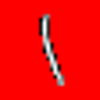

In [66]:
T.ToPILImage()(input2).resize((100,100))

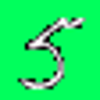

In [45]:
T.ToPILImage()(input1).resize((100,100))

In [18]:
type(embedding[0])

numpy.ndarray

In [19]:
list_test = []
test_arr = np.array([1,2,3])
list_test.append(test_arr)
list_test

[array([1, 2, 3])]

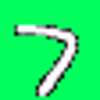

In [57]:
T.ToPILImage()(testset[17][0]).resize((100,100))

In [52]:
testset[11][1]

3

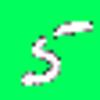

In [82]:
T.ToPILImage()(trainset[44][0]).resize((100,100))

## some testing ending